# Project 01 (basic) — reference solution: kNN by hand and the bias-variance tradeoff

**Goal:** build k-nearest neighbours entirely by hand (distance, neighbours, majority
vote), compare it with scikit-learn and make two lessons visible: why scaling decides
between success and failure for distance-based methods, and how the hyperparameter $k$
spans the arc from overfitting to underfitting.

**Data: real** — the penguins from module 02, classified from bill length and body mass.

**This is the fully worked solution.** All cells have been executed.

**Reference to the script:** sections 1.2, 1.3, 1.4.

## 1. Data and split

Training: 239, test: 103


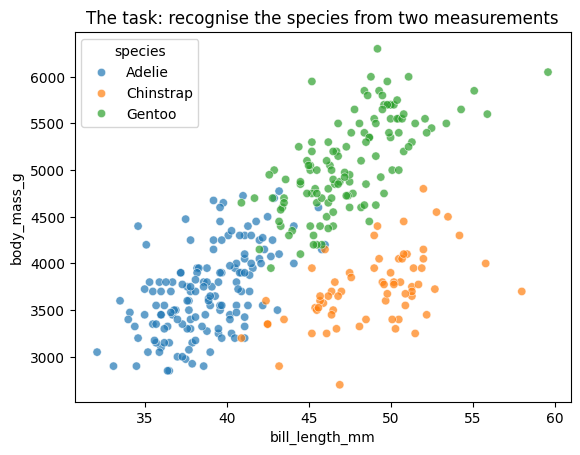

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split

df = sns.load_dataset("penguins").dropna(subset=["bill_length_mm", "body_mass_g", "species"])
X = df[["bill_length_mm", "body_mass_g"]].values
y = df["species"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)
print(f"Training: {len(X_train)}, test: {len(X_test)}")

sns.scatterplot(data=df, x="bill_length_mm", y="body_mass_g", hue="species", alpha=0.7)
plt.title("The task: recognise the species from two measurements"); plt.show()

## 2. Building kNN yourself

Three small functions (script 1.2):

1. `euclidean(a, b)`: $\sqrt{\sum_j (a_j - b_j)^2}$ — one line with numpy.
2. `knn_predict(point, X_tr, y_tr, k)`: distances to all training points, find the
   $k$ smallest (`np.argsort`), majority vote of the labels
   (`Counter(...).most_common(1)`).
3. `knn_accuracy(X_te, y_te, X_tr, y_tr, k)`: the share of correct predictions.

In [2]:
def euclidean(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def knn_predict(point, X_tr, y_tr, k):
    """Predicts the class of `point` by a majority vote of the k nearest neighbours."""
    distances = np.array([euclidean(point, x) for x in X_tr])
    nearest = np.argsort(distances)[:k]
    votes = Counter(y_tr[nearest])
    return votes.most_common(1)[0][0]

def knn_accuracy(X_te, y_te, X_tr, y_tr, k):
    predictions = np.array([knn_predict(p, X_tr, y_tr, k) for p in X_te])
    return (predictions == y_te).mean()

acc_raw = knn_accuracy(X_test, y_test, X_train, y_train, k=5)
print(f"Accuracy (k=5, UNscaled): {acc_raw:.3f}")

# Mini check: this should be disappointing (about 0.77) — you will see why in a moment
print(acc_raw < 0.85)

Accuracy (k=5, UNscaled): 0.767
True


## 3. The scaling lesson

About 77 % — weak. The reason: body mass is in the **thousands of grams**, bill length
in **dozens of millimetres**. In the Euclidean distance the bill length is therefore
practically invisible — kNN de facto classifies by mass alone.

**Task:** standardise both features: $z = (x - \bar{x}) / s$.
**Important (leakage, module 03!):** compute mean and spread on the **training data**
only and then apply them to both sets.

In [3]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train_s = (X_train - mean) / std
X_test_s = (X_test - mean) / std

acc_scaled = knn_accuracy(X_test_s, y_test, X_train_s, y_train, k=5)
print(f"Accuracy (k=5, scaled): {acc_scaled:.3f}   (before: {acc_raw:.3f})")

# Mini check:
print(acc_scaled > 0.94)

Accuracy (k=5, scaled): 0.951   (before: 0.767)
True


## 4. Cross-check with scikit-learn

Your hand-built kNN should deliver practically the same as `KNeighborsClassifier`.
*Small deviations (1 test point) are fine:* with exactly equal distances or a tie in the
vote, the two implementations decide differently — such **tie breaks** are a normal
implementation detail. (From now on you may always use sklearn; building it once
yourself was the point.)

In [4]:
from sklearn.neighbors import KNeighborsClassifier

sk = KNeighborsClassifier(n_neighbors=5).fit(X_train_s, y_train)
print(f"sklearn: {sk.score(X_test_s, y_test):.3f}  |  by hand: {acc_scaled:.3f}")

# Mini check: at most about 1 test point (out of 103) of difference
print(abs(sk.score(X_test_s, y_test) - acc_scaled) <= 1.5 / len(y_test))

sklearn: 0.961  |  by hand: 0.951
True


## 5. The bias-variance arc: sweeping k

**Task:** compute the train and test accuracy for
`k in [1, 3, 5, 9, 15, 31, 75, 151]` (feel free to use sklearn, it is faster)
and plot both curves against $k$. Describe what you see at the edges.

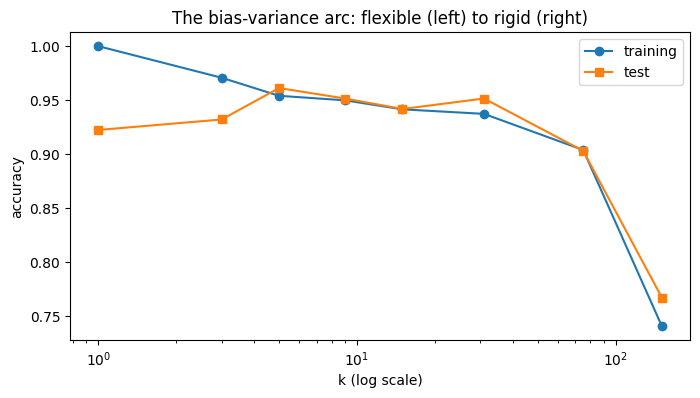

k=1:   train 1.000 vs. test 0.922  <- overfitting gap
k=151: train 0.741 vs. test 0.767 <- both bad: underfitting


In [5]:
ks = [1, 3, 5, 9, 15, 31, 75, 151]
train_acc, test_acc = [], []
for k in ks:
    m = KNeighborsClassifier(n_neighbors=k).fit(X_train_s, y_train)
    train_acc.append(m.score(X_train_s, y_train))
    test_acc.append(m.score(X_test_s, y_test))

plt.figure(figsize=(8, 4))
plt.plot(ks, train_acc, marker="o", label="training")
plt.plot(ks, test_acc, marker="s", label="test")
plt.xscale("log"); plt.xlabel("k (log scale)"); plt.ylabel("accuracy")
plt.title("The bias-variance arc: flexible (left) to rigid (right)")
plt.legend(); plt.show()

print(f"k=1:   train {train_acc[0]:.3f} vs. test {test_acc[0]:.3f}  <- overfitting gap")
print(f"k=151: train {train_acc[-1]:.3f} vs. test {test_acc[-1]:.3f} <- both bad: underfitting")

**Read the plot with script 1.3:**

- **Left (k=1):** training 100 %, test about 92 % — the gap is variance: the model
  memorises every training point including its noise (**overfitting**).
- **Middle (k about 5-31):** the test performance is best (about 95-96 %) — the sweet spot.
- **Right (k=151):** with 239 training points almost all neighbours vote — the model
  becomes a constant, training AND test collapse (**underfitting/bias**).

Note as well: the training curve falls monotonically — on training data the most flexible
model ALWAYS wins. That is exactly why k is never chosen on the training data.

## 6. Seeing the decision boundaries (given as is)

To finish, the decision boundaries for k=1 and k=31 — overfitting and smoothing
directly in the picture.

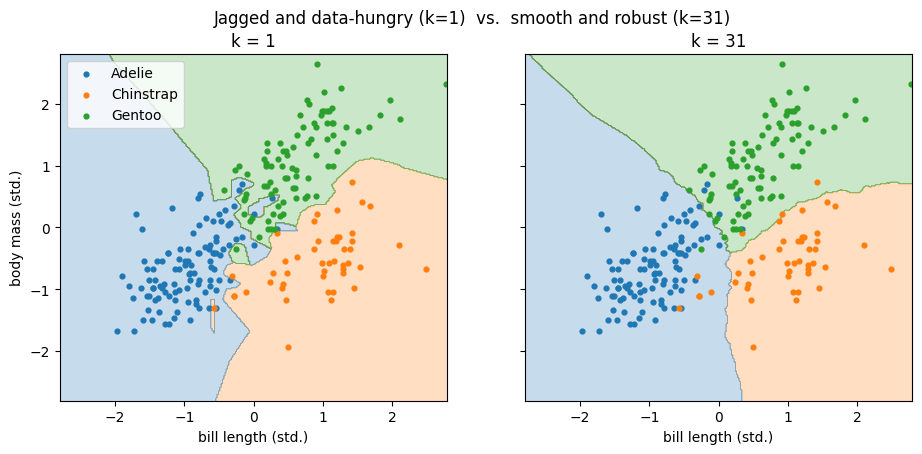

In [6]:
from matplotlib.colors import ListedColormap

def draw_boundary(k, ax):
    xx, yy = np.meshgrid(np.linspace(-2.8, 2.8, 300), np.linspace(-2.8, 2.8, 300))
    m = KNeighborsClassifier(n_neighbors=k).fit(X_train_s, y_train)
    classes = np.array(["Adelie", "Chinstrap", "Gentoo"])
    Z = np.searchsorted(classes, m.predict(np.c_[xx.ravel(), yy.ravel()])).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap=ListedColormap(["C0", "C1", "C2"]))
    for i, species in enumerate(classes):
        p = X_train_s[y_train == species]
        ax.scatter(p[:, 0], p[:, 1], s=12, color=f"C{i}", label=species)
    ax.set_title(f"k = {k}"); ax.set_xlabel("bill length (std.)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
draw_boundary(1, axes[0]); draw_boundary(31, axes[1])
axes[0].set_ylabel("body mass (std.)"); axes[0].legend()
plt.suptitle("Jagged and data-hungry (k=1)  vs.  smooth and robust (k=31)")
plt.show()

## Done — what you can do now

- implement kNN completely yourself (distance, neighbours, vote)
- explain AND show why distance-based methods need scaling (77 -> 95 %)
- read the bias-variance tradeoff off a real curve
- read decision boundaries as a picture of model complexity

**Bonus tasks:**
1. Take all 4 numerical features instead of 2 — does it get better? (And why can you no
   longer plot the boundary then?)
2. Replace the majority vote by **weighted** votes (weight 1/distance).
   In sklearn: `weights="distance"` — compare.
3. Measure the prediction time of your hand-written kNN for all test points (`%timeit`).
   Why is kNN slow at PREDICTION time while other models are slow at TRAINING time?